<a href="https://colab.research.google.com/github/subixu/MACHINE-LEARNING---ITA/blob/main/Copy_of_Machine_learning_assign.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/IBM/employee-attrition-aif360/master/data/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

HTTPError: HTTP Error 404: Not Found

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/IBM/employee-attrition-aif360/master/data/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

df.head()

HTTPError: HTTP Error 404: Not Found

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

df.head()

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/Giskard-AI/examples/main/datasets/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  704

In [ ]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [ ]:
print("Churn Distribution:")
print(df["Churn"].value_counts())

Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [ ]:
# Step 5: Data Preprocessing

import numpy as np

# Make a copy of the original dataset
data = df.copy()

# Remove irrelevant customer ID
data.drop("customerID", axis=1, inplace=True)

# Convert TotalCharges to numeric
# Blank values will become NaN
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")

# Check missing values before handling
print("Missing values before handling:")
print(data.isnull().sum())

# Fill missing numerical values with median
data["TotalCharges"].fillna(data["TotalCharges"].median(), inplace=True)

# Convert target variable Churn into numerical values
data["Churn"] = data["Churn"].map({"No": 0, "Yes": 1})

# Separate features and target
X = data.drop("Churn", axis=1)
y = data["Churn"]

# Convert categorical columns into numerical columns
X = pd.get_dummies(X, drop_first=True)

print("\nMissing values after handling:")
print(X.isnull().sum().sum())

print("\nPreprocessed dataset shape:")
print(X.shape)

print("\nTarget shape:")
print(y.shape)

Missing values before handling:
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Missing values after handling:
0

Preprocessed dataset shape:
(7043, 30)

Target shape:
(7043,)


/tmp/ipykernel_4366/2888614972.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["TotalCharges"].fillna(data["TotalCharges"].median(), inplace=True)


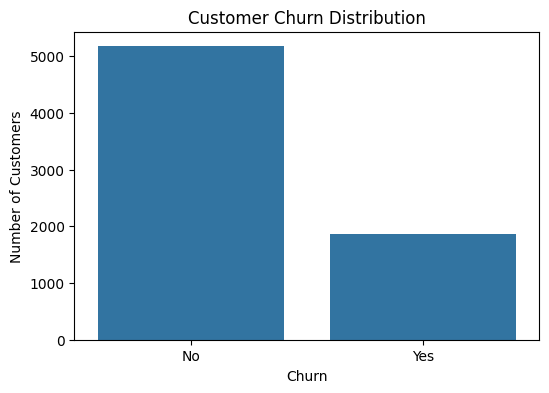

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Churn distribution
plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

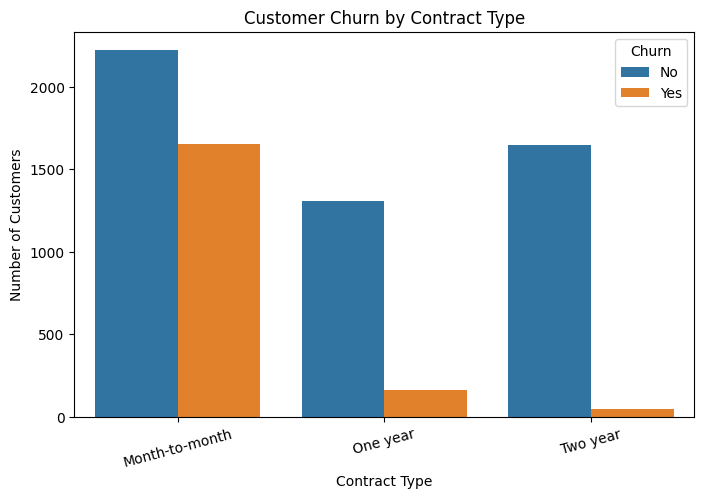

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)
plt.show()

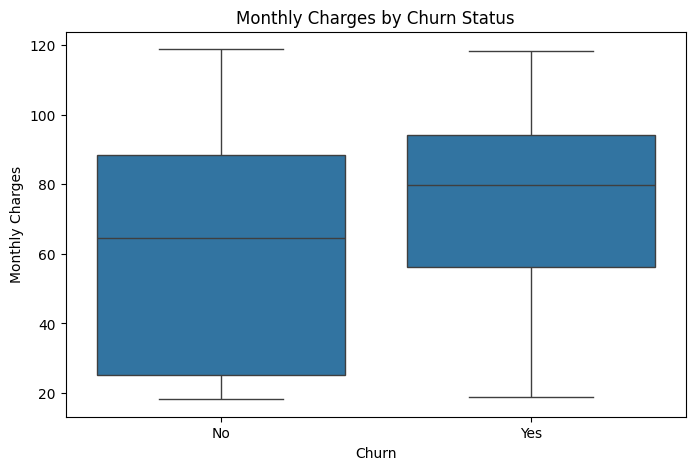

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

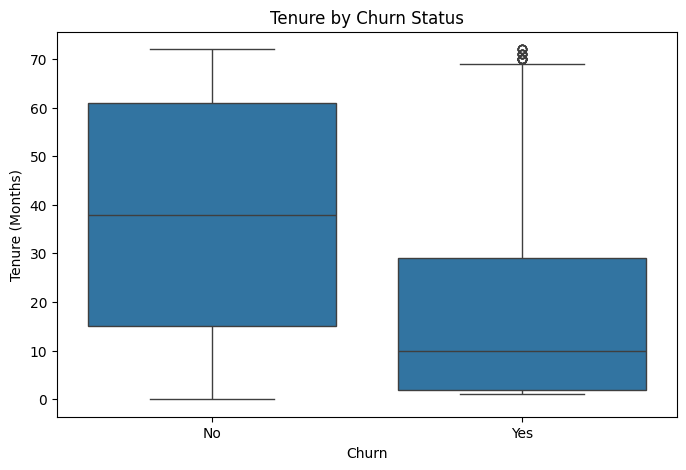

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Tenure by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.show()

In [ ]:
# Step 7: Train-Test Split and Feature Scaling

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Feature scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

print("\nData splitting and scaling completed successfully!")

Training data shape: (5634, 30)
Testing data shape: (1409, 30)
Training target shape: (5634,)
Testing target shape: (1409,)

Data splitting and scaling completed successfully!


In [ ]:
# Step 8: Train Machine Learning Models

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

# Create models
logistic_model = LogisticRegression(max_iter=1000, random_state=42)

decision_tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

naive_bayes_model = GaussianNB()

# Train the models
logistic_model.fit(X_train_scaled, y_train)

decision_tree_model.fit(X_train_scaled, y_train)

naive_bayes_model.fit(X_train_scaled, y_train)

print("All three models trained successfully!")

All three models trained successfully!


In [ ]:
# Step 8.2: Predictions

y_pred_logistic = logistic_model.predict(X_test_scaled)

y_pred_tree = decision_tree_model.predict(X_test_scaled)

y_pred_nb = naive_bayes_model.predict(X_test_scaled)

print("Predictions completed successfully!")

Predictions completed successfully!


In [ ]:
# Step 8.3: Model Evaluation

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Logistic Regression": y_pred_logistic,
    "Decision Tree": y_pred_tree,
    "Naive Bayes": y_pred_nb
}

results = []

for name, predictions in models.items():
    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"]
)

print(results_df)

                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.806955   0.658385  0.566845  0.609195
1        Decision Tree  0.794180   0.629630  0.545455  0.584527
2          Naive Bayes  0.655784   0.426877  0.866310  0.571933


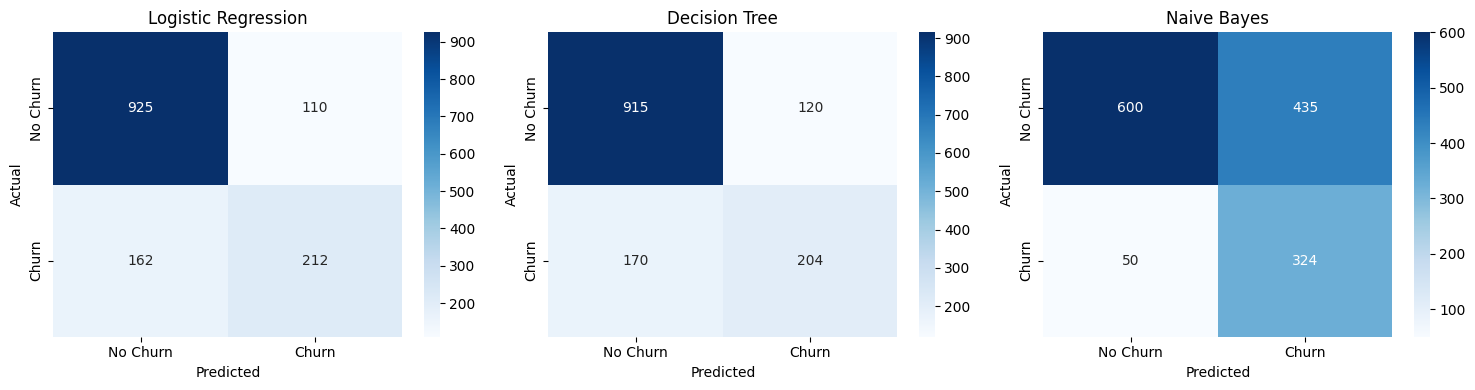

In [ ]:
# Step 9: Confusion Matrices

from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

predictions = [
    ("Logistic Regression", y_pred_logistic),
    ("Decision Tree", y_pred_tree),
    ("Naive Bayes", y_pred_nb)
]

for ax, (name, predictions_model) in zip(axes, predictions):
    cm = confusion_matrix(y_test, predictions_model)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        xticklabels=["No Churn", "Churn"],
        yticklabels=["No Churn", "Churn"]
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

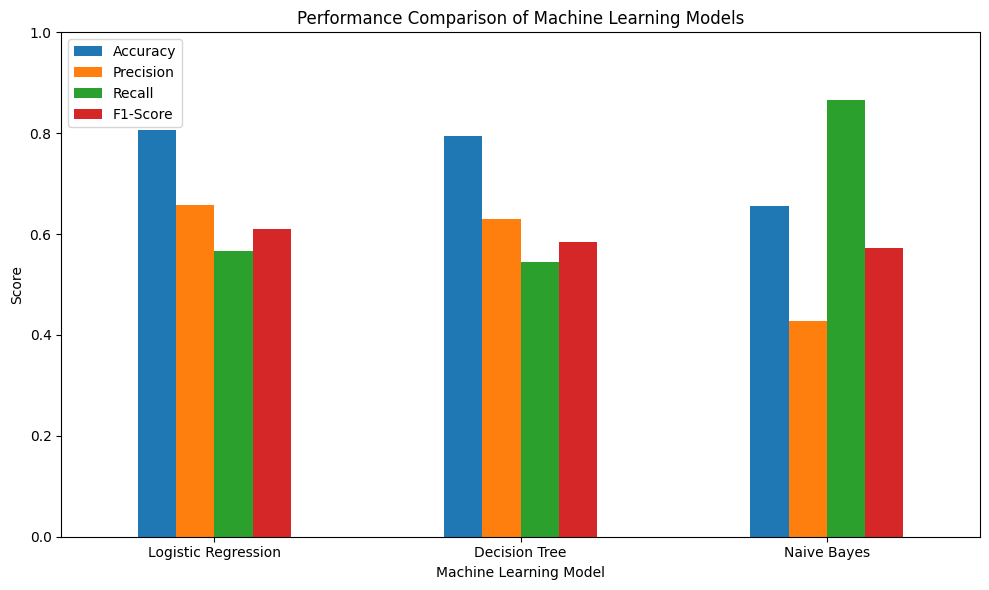

In [ ]:
# Model Performance Comparison

results_plot = results_df.set_index("Model")

results_plot[["Accuracy", "Precision", "Recall", "F1-Score"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Performance Comparison of Machine Learning Models")
plt.xlabel("Machine Learning Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Identify the best-performing model

best_model = results_df.loc[
    results_df["F1-Score"].idxmax()
]

print("Best Performing Model:")
print(best_model)

Best Performing Model:
Model        Logistic Regression
Accuracy                0.806955
Precision               0.658385
Recall                  0.566845
F1-Score                0.609195
Name: 0, dtype: object


In [ ]:
# Step 10.1: Prepare data for K-Means Clustering

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Scale all customer features for clustering
cluster_scaler = StandardScaler()
X_cluster = cluster_scaler.fit_transform(X)

print("Clustering data prepared successfully!")
print("Clustering data shape:", X_cluster.shape)

Clustering data prepared successfully!
Clustering data shape: (7043, 30)


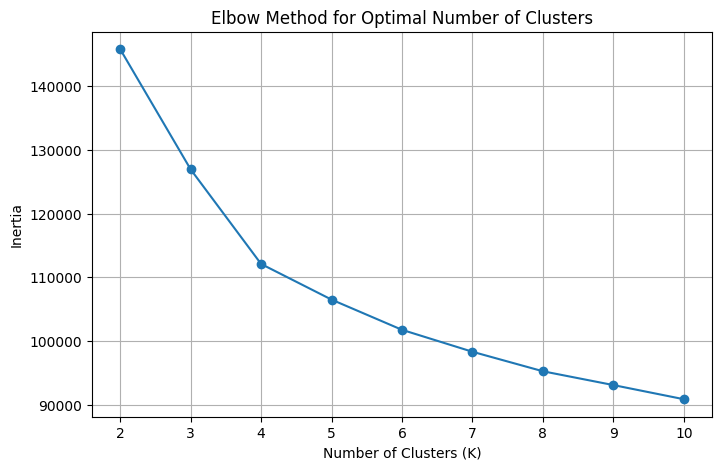

In [ ]:
# Step 10.2: Elbow Method

inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_cluster)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker="o")
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

In [ ]:
# Step 10.3: K-Means Clustering with 4 Clusters

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

# Assign each customer to a cluster
clusters = kmeans.fit_predict(X_cluster)

# Add cluster labels to the original data
data["Cluster"] = clusters

print("K-Means clustering completed successfully!")
print("\nNumber of customers in each cluster:")
print(data["Cluster"].value_counts().sort_index())

K-Means clustering completed successfully!

Number of customers in each cluster:
Cluster
0     682
1    2735
2    2100
3    1526
Name: count, dtype: int64


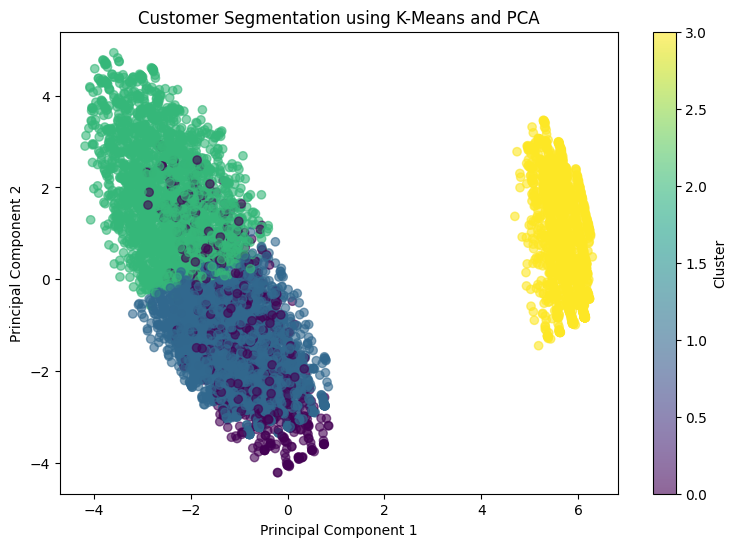

Explained variance ratio:
[0.33177964 0.11987987]
Total variance explained: 0.4516595084286805


In [ ]:
# Step 10.4: PCA Visualization of Customer Clusters

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_cluster)

plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    cmap="viridis",
    alpha=0.6
)

plt.title("Customer Segmentation using K-Means and PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(scatter, label="Cluster")
plt.show()

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print("Total variance explained:",
      pca.explained_variance_ratio_.sum())

In [ ]:
# Step 11: Analyze Customer Segments

cluster_analysis = data.groupby("Cluster").agg(
    Customers=("Churn", "count"),
    Churned=("Churn", "sum"),
    Churn_Rate=("Churn", "mean"),
    Avg_Tenure=("tenure", "mean"),
    Avg_Monthly_Charges=("MonthlyCharges", "mean"),
    Avg_Total_Charges=("TotalCharges", "mean")
)

# Convert churn rate to percentage
cluster_analysis["Churn_Rate"] = cluster_analysis["Churn_Rate"] * 100

print("Customer Segment Analysis:")
print(cluster_analysis.round(2))

Customer Segment Analysis:
         Customers  Churned  Churn_Rate  Avg_Tenure  Avg_Monthly_Charges  \
Cluster                                                                    
0              682      170       24.93       31.74                42.03   
1             2735     1277       46.69       15.54                73.99   
2             2100      309       14.71       55.83                91.87   
3             1526      113        7.40       30.55                21.08   

         Avg_Total_Charges  
Cluster                     
0                  1500.13  
1                  1172.30  
2                  5153.66  
3                   668.10  


In [ ]:
# Step 11: Analyze Customer Segments

cluster_analysis = data.groupby("Cluster").agg(
    Customers=("Churn", "count"),
    Churned=("Churn", "sum"),
    Churn_Rate=("Churn", "mean"),
    Avg_Tenure=("tenure", "mean"),
    Avg_Monthly_Charges=("MonthlyCharges", "mean"),
    Avg_Total_Charges=("TotalCharges", "mean")
)

# Convert churn rate to percentage
cluster_analysis["Churn_Rate"] = cluster_analysis["Churn_Rate"] * 100

print("Customer Segment Analysis:")
print(cluster_analysis.round(2))

Customer Segment Analysis:
         Customers  Churned  Churn_Rate  Avg_Tenure  Avg_Monthly_Charges  \
Cluster                                                                    
0              682      170       24.93       31.74                42.03   
1             2735     1277       46.69       15.54                73.99   
2             2100      309       14.71       55.83                91.87   
3             1526      113        7.40       30.55                21.08   

         Avg_Total_Charges  
Cluster                     
0                  1500.13  
1                  1172.30  
2                  5153.66  
3                   668.10  


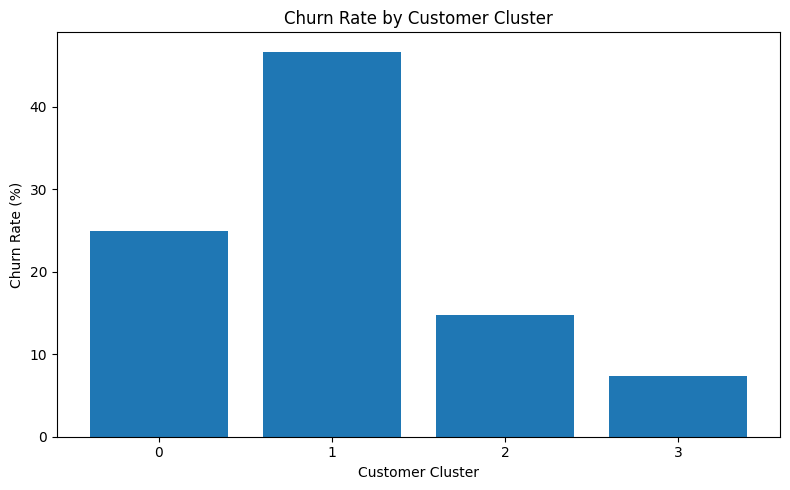

In [ ]:
# Churn Rate by Customer Cluster

plt.figure(figsize=(8, 5))

plt.bar(
    cluster_analysis.index.astype(str),
    cluster_analysis["Churn_Rate"]
)

plt.title("Churn Rate by Customer Cluster")
plt.xlabel("Customer Cluster")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Step 12.1: Final Customer Segment Summary

final_summary = cluster_analysis.copy()

final_summary["Risk Level"] = final_summary["Churn_Rate"].apply(
    lambda x: "High Risk" if x >= 30 else "Low/Medium Risk"
)

print("FINAL CUSTOMER SEGMENT SUMMARY")
print(final_summary.round(2))

FINAL CUSTOMER SEGMENT SUMMARY
         Customers  Churned  Churn_Rate  Avg_Tenure  Avg_Monthly_Charges  \
Cluster                                                                    
0              682      170       24.93       31.74                42.03   
1             2735     1277       46.69       15.54                73.99   
2             2100      309       14.71       55.83                91.87   
3             1526      113        7.40       30.55                21.08   

         Avg_Total_Charges       Risk Level  
Cluster                                      
0                  1500.13  Low/Medium Risk  
1                  1172.30        High Risk  
2                  5153.66  Low/Medium Risk  
3                   668.10  Low/Medium Risk  


In [ ]:
# Step 12.2: Retention Recommendations

print("RETENTION RECOMMENDATIONS\n")

for cluster in cluster_analysis.index:
    churn_rate = cluster_analysis.loc[cluster, "Churn_Rate"]
    tenure = cluster_analysis.loc[cluster, "Avg_Tenure"]
    monthly = cluster_analysis.loc[cluster, "Avg_Monthly_Charges"]

    print(f"Cluster {cluster}:")
    print(f"  Churn Rate: {churn_rate:.2f}%")
    print(f"  Average Tenure: {tenure:.2f} months")
    print(f"  Average Monthly Charges: ${monthly:.2f}")

    if churn_rate >= 30:
        print("  Recommendation: High-priority retention campaign,")
        print("  personalized offers, service support, and contract incentives.")
    elif churn_rate >= 20:
        print("  Recommendation: Targeted engagement, loyalty benefits,")
        print("  and proactive customer support.")
    else:
        print("  Recommendation: Maintain engagement and provide")
        print("  loyalty rewards to prevent future churn.")

    print()


RETENTION RECOMMENDATIONS

Cluster 0:
  Churn Rate: 24.93%
  Average Tenure: 31.74 months
  Average Monthly Charges: $42.03
  Recommendation: Targeted engagement, loyalty benefits,
  and proactive customer support.

Cluster 1:
  Churn Rate: 46.69%
  Average Tenure: 15.54 months
  Average Monthly Charges: $73.99
  Recommendation: High-priority retention campaign,
  personalized offers, service support, and contract incentives.

Cluster 2:
  Churn Rate: 14.71%
  Average Tenure: 55.83 months
  Average Monthly Charges: $91.87
  Recommendation: Maintain engagement and provide
  loyalty rewards to prevent future churn.

Cluster 3:
  Churn Rate: 7.40%
  Average Tenure: 30.55 months
  Average Monthly Charges: $21.08
  Recommendation: Maintain engagement and provide
  loyalty rewards to prevent future churn.



In [ ]:
# Step 12.3: Final Project Summary

best_model_name = best_model["Model"]
best_accuracy = best_model["Accuracy"]
best_f1 = best_model["F1-Score"]

print("========== FINAL PROJECT SUMMARY ==========")
print(f"Total Customers Analyzed: {len(data)}")
print(f"Number of Customer Segments: 4")
print(f"Best Classification Model: {best_model_name}")
print(f"Best Model Accuracy: {best_accuracy:.4f}")
print(f"Best Model F1-Score: {best_f1:.4f}")
print(f"Highest-Risk Cluster: Cluster {high_risk_cluster}")
print(f"Highest Cluster Churn Rate: {highest_churn_rate:.2f}%")
print("============================================")

========== FINAL PROJECT SUMMARY ==========
Total Customers Analyzed: 7043
Number of Customer Segments: 4
Best Classification Model: Logistic Regression
Best Model Accuracy: 0.8070
Best Model F1-Score: 0.6092


NameError: name 'high_risk_cluster' is not defined